In [2]:
from GradientGang.Pipeline.DataLoader.DataLoader import DataModule

params = {
    'data_dir': "../dataset/PirateProcessed/",
    'train_file_name': "pirate_pain_train.csv",
    'train_file_name_labels': "pirate_pain_train_labels.csv",
    'test_file_name': "pirate_pain_test.csv",
    'batch_size': 32,
    'num_workers': 0,
    'val_split': 0.1,
    'shuffle': True,
}

dataLoader = DataModule(params=params)
dataLoader.setup(stage='fit')

trainLoader = dataLoader.train_dataloader()
valLoader = dataLoader.val_dataloader()

dataLoader.setup(stage='test')
testLoader = dataLoader.test_dataloader()

In [3]:
for batch in trainLoader:
    (time_series, global_features), labels = batch
    print("Train Batch - Time Series Shape:", time_series.shape)
    print("Train Batch - Global Features Shape:", global_features.shape)
    print("Train Batch - Labels Shape:", labels.shape)
    break

Train Batch - Time Series Shape: torch.Size([32, 34, 160])
Train Batch - Global Features Shape: torch.Size([32, 1])
Train Batch - Labels Shape: torch.Size([32])


In [4]:
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder
from torchsummary import summary

In [5]:
# Reload the modules to get the latest changes
import importlib
import GradientGang.Pipeline.Architectures.LightningAutoencoder
import GradientGang.Pipeline.Architectures.Decoder
importlib.reload(GradientGang.Pipeline.Architectures.Decoder)
importlib.reload(GradientGang.Pipeline.Architectures.LightningAutoencoder)
from GradientGang.Pipeline.Architectures.LightningAutoencoder import LightningAutoencoder

In [6]:
architectureParams = {
    "LearningRate": 0.001,
    "Patience": 5,
    "RegularizationWeight": 0.1,
    "EncoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "LSTM",
                "params": {
                    "input_size": 34,
                    "hidden_size": 64,
                    "num_layers": 1,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.0,
                    "bidirectional": False
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,  # LSTM hidden_size
                    "out_features": 128,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            }
        ]
    },
    "DecoderParams": {
        "activation_function": "GELU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 128,
                    "out_features": 64,  # Changed to match LSTM input_size
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "LSTM",
                "params": {
                    "input_size": 64,  # This will receive (batch, seq_len, 64)
                    "hidden_size": 34,
                    "num_layers": 1,
                    "bias": True,
                    "batch_first": True,
                    "dropout": 0.0,
                    "bidirectional": False
                }
            }
        ]
    },
    "FeedForwardParams": {
        "activation_function": "ReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 129,
                    "out_features": 64,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
            {
                "name": "Linear",
                "params": {
                    "in_features": 64,
                    "out_features": 10,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            }
        ]
    },
    "GlobalFFEncoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
        ]
    },
    "GlobalFFDecoderParams": {
        "activation_function": "LeakyReLU",
        "layer_type": [
            {
                "name": "Linear",
                "params": {
                    "in_features": 1,
                    "out_features": 1,
                    "bias": True,
                    "device": None,
                    "dtype": None
                }
            },
        ]
    },
    "OutputDim": 3
}

autoencoder = LightningAutoencoder(architectureParams)

In [7]:
# architectureParams = {
#     "LearningRate": 0.001,
#     "Patience": 5,
#     "RegularizationWeight": 0.1,
#     "EncoderParams": {
#         "activation_function": "GELU",
#         "layer_type": [
#             {
#                 "name": "Conv1d",
#                 "params": {
#                     "in_channels": 34,
#                     "out_channels": 16,
#                     "kernel_size": 10,
#                     "stride": 1,
#                     "padding": 1,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 },
#             },
#             {
#                 "name": "Conv1d",
#                 "params": {
#                     "in_channels": 16,
#                     "out_channels": 32,
#                     "kernel_size": 3,
#                     "stride": 1,
#                     "padding": 1,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 },
#             },
#             {
#                 "name": "Conv1d",
#                 "params": {
#                     "in_channels": 32,
#                     "out_channels": 64,
#                     "kernel_size": 3,
#                     "stride": 1,
#                     "padding": 1,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 },
#             },
#             {
#                 "name": "Flatten",
#                 "params": {}
#             },
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 9792, 
#                     "out_features": 128,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             }
#         ]
#     },
#     "DecoderParams": {
#         "activation_function": "GELU",
#         "layer_type": [
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 128,
#                     "out_features": 9792,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#             {
#                 "name": "Unflatten",
#                 "params": {
#                     "dim": 1,
#                     "unflattened_size": [64, 153]
#                 }
#             },
#             {
#                 "name": "ConvTranspose1d",
#                 "params": {
#                     "in_channels": 64,
#                     "out_channels": 32,
#                     "kernel_size": 3,
#                     "stride": 1,
#                     "padding": 1,
#                     "output_padding": 0,
#                     "groups": 1,
#                     "dilation": 1,
#                     "padding_mode": "zeros",
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#             {
#                 "name": "ConvTranspose1d",
#                 "params": {
#                     "in_channels": 32,
#                     "out_channels": 16,
#                     "kernel_size": 3,
#                     "stride": 1,
#                     "padding": 1,
#                     "output_padding": 0,
#                     "groups": 1,
#                     "dilation": 1,
#                     "padding_mode": "zeros",
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#             {
#                 "name": "ConvTranspose1d",
#                 "params": {
#                     "in_channels": 16,
#                     "out_channels": 34,
#                     "kernel_size": 10,
#                     "stride": 1,
#                     "padding": 1,
#                     "output_padding": 0,
#                     "groups": 1,
#                     "dilation": 1,
#                     "padding_mode": "zeros",
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             }
#         ]
#     },
#     "FeedForwardParams": {
#         "activation_function": "ReLU",
#         "layer_type": [
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 129,
#                     "out_features": 64,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 64,
#                     "out_features": 10,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             }
#         ]
#     },
#     "GlobalFFEncoderParams": {
#         "activation_function": "LeakyReLU",
#         "layer_type": [
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 1,
#                     "out_features": 1,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#         ]
#     },
#     "GlobalFFDecoderParams": {
#         "activation_function": "LeakyReLU",
#         "layer_type": [
#             {
#                 "name": "Linear",
#                 "params": {
#                     "in_features": 1,
#                     "out_features": 1,
#                     "bias": True,
#                     "device": None,
#                     "dtype": None
#                 }
#             },
#         ]
#     },
#     "OutputDim": 3
# }

# autoencoder = LightningAutoencoder(architectureParams)

In [8]:
# Debug: Test the autoencoder forward pass
import torch
with torch.no_grad():
    test_batch = next(iter(trainLoader))
    (test_time_series, test_global_features), test_labels = test_batch
    print("Input time series shape:", test_time_series.shape)
    print("Input global features shape:", test_global_features.shape)
    
    predictions, (decoded, decoded_globalFeatures) = autoencoder((test_time_series, test_global_features))
    
    print("\nOutput predictions shape:", predictions.shape)
    print("Decoded time series shape:", decoded.shape)
    print("Decoded global features shape:", decoded_globalFeatures.shape)
    
    print("\nExpected decoded time series shape:", test_time_series.shape)
    print("Match?", decoded.shape == test_time_series.shape)

Input time series shape: torch.Size([32, 34, 160])
Input global features shape: torch.Size([32, 1])

Output predictions shape: torch.Size([32, 3])
Decoded time series shape: torch.Size([32, 34, 160])
Decoded global features shape: torch.Size([32, 1])

Expected decoded time series shape: torch.Size([32, 34, 160])
Match? True


In [9]:
from pytorch_lightning import Trainer

trainer = Trainer(max_epochs=10, enable_progress_bar=True,)
trainer.fit(autoencoder, trainLoader, valLoader)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3050 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | encoder          | Encoder           | 33.9 K | train
1 | decoder          | Decoder           | 21.9 K | train
2 | globalff_encoder | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\marti\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\marti\ANN-Challenges\.venv\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [12]:
#Compute F1 score on val set
from torchmetrics import F1Score
import torch

all_preds = []
all_labels = []
for batch in valLoader:
    x, labels = batch
    with torch.no_grad():
        preds = autoencoder(x)[0]
    all_preds.extend(preds.argmax(dim=1).cpu().numpy())
    all_labels.extend(labels)

print(all_preds)
print(all_labels)

f1 = F1Score(task= "multiclass", num_classes=3, average='macro')
f1 = f1(torch.tensor(all_preds),torch.tensor(all_labels))
print("Validation F1 Score:", f1)

[np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0)]
[tensor(0), tensor(0), tensor(2), tensor(0), tensor(2), tensor(0), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1

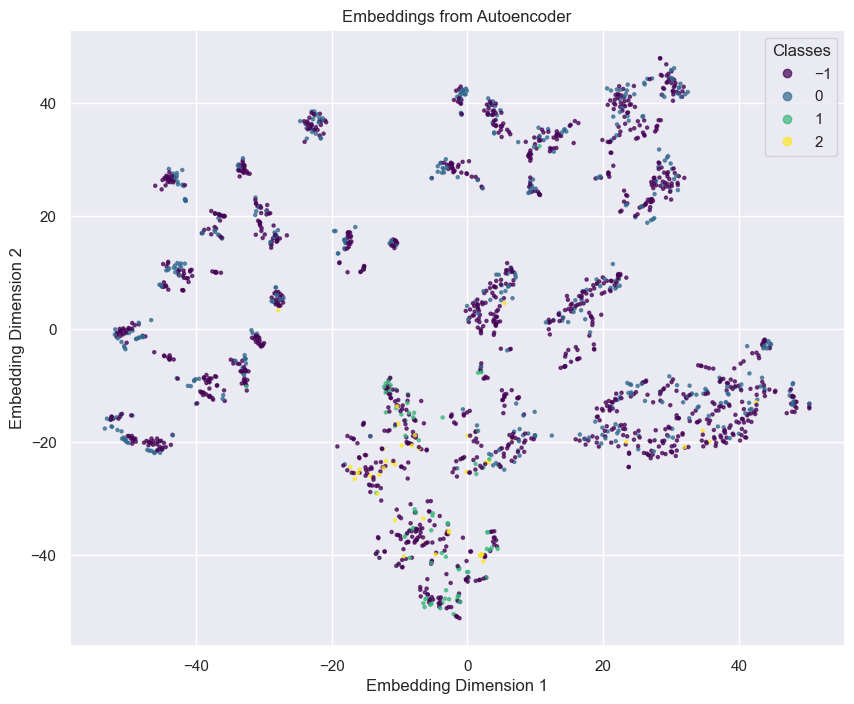

In [16]:
# plot embeddings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
sns.set_theme()

embeddings = []
labels_list = []
for batch in trainLoader:
    (time_series, global_features), labels = batch
    with torch.no_grad():
        # Encoder expects the time-series tensor (batch, channels, seq_len)
        embedding = autoencoder.encoder(time_series)
    embeddings.append(embedding.cpu())
    labels_list.append(labels)

embeddings = torch.cat(embeddings, dim=0).numpy()
labels_list = torch.cat(labels_list, dim=0).numpy()

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels_list, alpha=0.7, cmap='viridis', s=5)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title('Embeddings from Autoencoder')
plt.xlabel('Embedding Dimension 1')
plt.ylabel('Embedding Dimension 2')
plt.show()